In [1]:
import os 
import torch
import numpy as np
from PIL import Image
import albumentations as A
from torch.utils.data import Dataset , DataLoader
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim

In [2]:
LEARNING_RATE = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 8
NUM_EPOCHS = 4
NUM_WORKERS = 2
PIN_MEMORY = True
LOAD_MODEL = False
TRAIN_IMG_DIR = "/kaggle/input/person-segmentation/train/image"
TRAIN_MASK_DIR = "/kaggle/input/person-segmentation/train/mask"
VAL_IMG_DIR = "/kaggle/input/person-segmentation/test/image"
VAL_MASK_DIR = "/kaggle/input/person-segmentation/test/mask"




In [3]:

class PersonSegmentData(Dataset):

    def __init__(self, image_dir, mask_dir, transform=None) -> None:
        super(PersonSegmentData, self).__init__()
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = os.listdir(image_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image_path = os.path.join(self.image_dir, self.images[index])
        mask_path = os.path.join(
            self.mask_dir, self.images[index].replace(".jpg", ".png"))

        image = np.array(Image.open(image_path).convert("RGB"))
        mask = np.array(Image.open(mask_path).convert("L"),
                        dtype=np.float32)  # l -> grayscale
        mask[mask == 255.0] = 1.0

        if self.transform is not None:
            augemantations = self.transform(image=image, mask=mask)
            image = augemantations['image']
            mask = augemantations['mask']
        return image, mask


def get_data_loaders(
        train_dir, train_mask_dir, val_dir, val_maskdir, batch_size,
        train_transform, val_transform, num_workers=4, pin_memory=True):

    train_ds = PersonSegmentData(
        image_dir=train_dir, mask_dir=train_mask_dir,
        transform=train_transform)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        num_workers=num_workers,
        pin_memory=pin_memory,
        shuffle=True,
    )

    val_ds = PersonSegmentData(
        image_dir=val_dir,
        mask_dir=val_maskdir,
        transform=val_transform,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        num_workers=num_workers,
        pin_memory=pin_memory,
        shuffle=False,
    )

    return train_loader, val_loader





def save_checkpoint(state, filename="resize.pth.tar"):
    print("=> Saving checkpoint")
    torch.save(state, filename)


In [4]:
train_transform = A.Compose(
    [
        A.Normalize(
            mean=[0.0, 0.0, 0.0],
            std=[1.0, 1.0, 1.0],
            max_pixel_value=255.0,
        ),
        ToTensorV2(),
    ],
)

val_transforms = A.Compose(
    [
        A.Normalize(
            mean=[0.0, 0.0, 0.0],
            std=[1.0, 1.0, 1.0],
            max_pixel_value=255.0,
        ),
        ToTensorV2(),
    ],
)

train_loader , val_loader = get_data_loaders(
    TRAIN_IMG_DIR,
    TRAIN_MASK_DIR,
    VAL_IMG_DIR,
    VAL_MASK_DIR,
    BATCH_SIZE,
    train_transform, 
    val_transforms
)

/opt/conda/lib/python3.7/site-packages/torch/utils/data/dataloader.py:490: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  cpuset_checked))


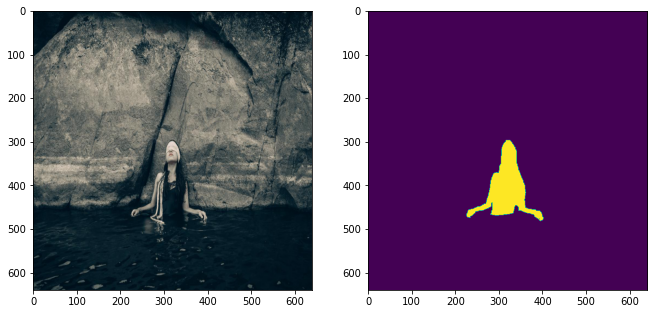

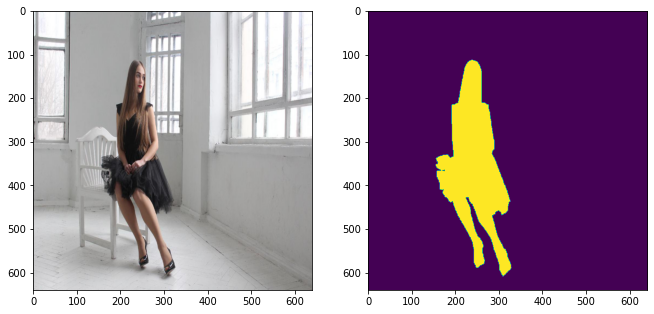

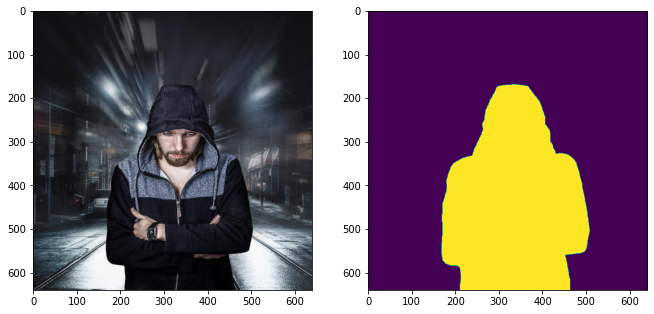

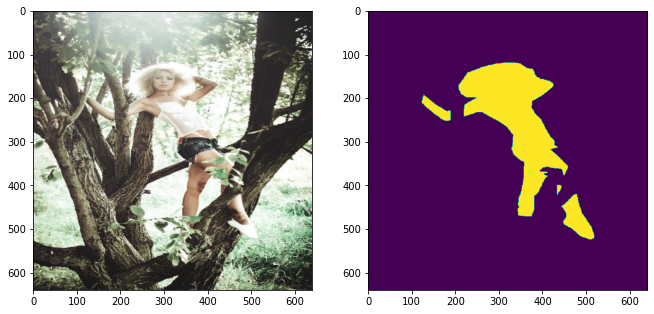

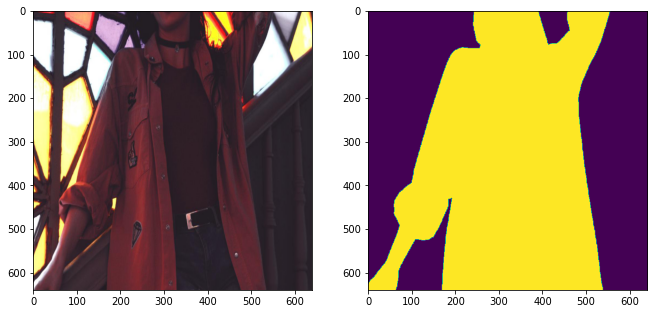

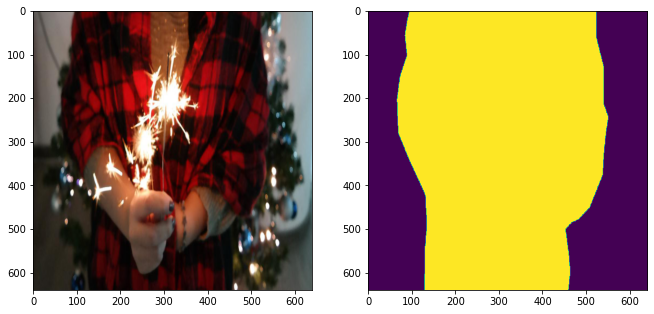

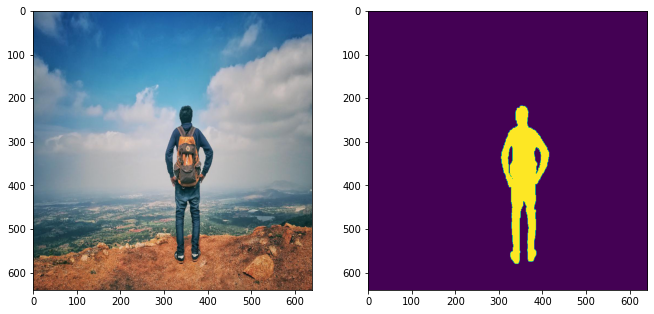

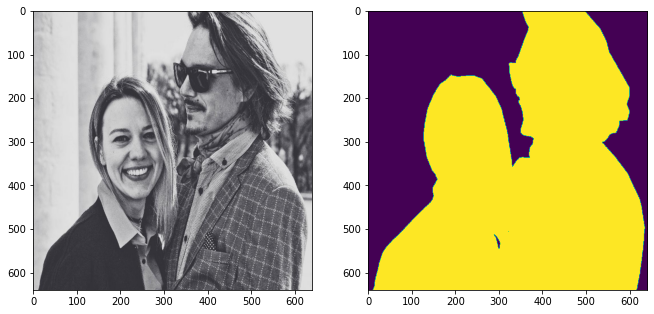

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def show_transformed(train_loader):
    batch = next(iter(train_loader))
    images, labels = batch

    for img , mask in zip(images,labels):
        plt.figure(figsize=(11,11))

        plt.subplot(1,2,1)
        plt.imshow(np.transpose(img , (1,2,0)))

        plt.subplot(1,2,2)
        plt.imshow(mask.reshape(mask.shape[0],mask.shape[1] , 1))


    
    
show_transformed(val_loader)

In [6]:
import torchvision.models as models
class ResNet_50(nn.Module):
    def __init__(self, output_layer=None):
        super(ResNet_50, self).__init__()
        self.pretrained = models.resnet50(pretrained=True)
        self.output_layer = output_layer
        self.layers = list(self.pretrained._modules.keys())
        self.layer_count = 0
        for l in self.layers:
            if l != self.output_layer:
                self.layer_count += 1
            else:
                break
        for i in range(1, len(self.layers)-self.layer_count):
            self.dummy_var = self.pretrained._modules.pop(self.layers[-i])
        self.net = nn.Sequential(self.pretrained._modules)
        self.pretrained = None

    def forward(self, x):
        x = self.net(x)
        return x



In [7]:
class Atrous_Convolution(nn.Module):
    """Compute Atrous/Dilated Convolution.
    """

    def __init__(
            self, input_channels, kernel_size, pad, dilation_rate,
            output_channels=256):
        super(Atrous_Convolution, self).__init__()

        self.conv = nn.Conv2d(in_channels=input_channels,
                              out_channels=output_channels,
                              kernel_size=kernel_size, padding=pad,
                              dilation=dilation_rate, bias=False)

        self.batchnorm = nn.BatchNorm2d(output_channels)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):

        x = self.conv(x)
        x = self.batchnorm(x)
        x = self.relu(x)
        return x


class ASSP(nn.Module):
    """Atrous Spatial Pyramid pooling layer
    """

    def __init__(self, in_channles, out_channles):
        """Atrous Spatial Pyramid pooling layer
        Args:
            in_channles (int): No of input channel for Atrous_Convolution.
            out_channles (int): No of output channel for Atrous_Convolution.
        """
        super(ASSP, self).__init__()
        self.conv_1x1 = Atrous_Convolution(
            input_channels=in_channles, output_channels=out_channles,
            kernel_size=1, pad=0, dilation_rate=1)

        self.conv_6x6 = Atrous_Convolution(
            input_channels=in_channles, output_channels=out_channles,
            kernel_size=3, pad=6, dilation_rate=6)

        self.conv_12x12 = Atrous_Convolution(
            input_channels=in_channles, output_channels=out_channles,
            kernel_size=3, pad=12, dilation_rate=12)

        self.conv_18x18 = Atrous_Convolution(
            input_channels=in_channles, output_channels=out_channles,
            kernel_size=3, pad=18, dilation_rate=18)

        self.image_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(
                in_channels=in_channles, out_channels=out_channles,
                kernel_size=1, stride=1, padding=0, dilation=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True))

        self.final_conv = Atrous_Convolution(
            input_channels=out_channles * 5, output_channels=out_channles,
            kernel_size=1, pad=0, dilation_rate=1)

    def forward(self, x):
        x_1x1 = self.conv_1x1(x)
        x_6x6 = self.conv_6x6(x)
        x_12x12 = self.conv_12x12(x)
        x_18x18 = self.conv_18x18(x)
        img_pool_opt = self.image_pool(x)
        img_pool_opt = F.interpolate(
            img_pool_opt, size=x_18x18.size()[2:],
            mode='bilinear', align_corners=True)
        concat = torch.cat(
            (x_1x1, x_6x6, x_12x12, x_18x18, img_pool_opt),
            dim=1)
        x_final_conv = self.final_conv(concat)
        return x_final_conv


In [8]:
class Deeplabv3Plus(nn.Module):
    def __init__(self, num_classes):

        super(Deeplabv3Plus, self).__init__()

        self.backbone = ResNet_50(output_layer='layer3')

        self.low_level_features = ResNet_50(output_layer='layer1')

        self.assp = ASSP(in_channles=1024, out_channles=256)

        self.conv1x1 = Atrous_Convolution(
            input_channels=256, output_channels=48, kernel_size=1,
            dilation_rate=1, pad=0)

        self.conv_3x3 = nn.Sequential(
            nn.Conv2d(304, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )

        self.classifer = nn.Conv2d(256, num_classes, 1)

    def forward(self, x):
        x_backbone = self.backbone(x)
        x_low_level = self.low_level_features(x)
        x_assp = self.assp(x_backbone)
        x_assp_upsampled = F.interpolate(
            x_assp, scale_factor=(4, 4),
            mode='bilinear', align_corners=True)
        x_conv1x1 = self.conv1x1(x_low_level)
        x_cat = torch.cat([x_conv1x1, x_assp_upsampled], dim=1)
        x_3x3 = self.conv_3x3(x_cat)
        x_3x3_upscaled = F.interpolate(
            x_3x3, scale_factor=(4, 4),
            mode='bilinear', align_corners=True)
        x_out = self.classifer(x_3x3_upscaled)
        return x_out


In [9]:

import torch.nn.functional as F
class DiceBCELoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(DiceBCELoss, self).__init__()
        self.bce_losss = nn.BCEWithLogitsLoss()

    def forward(self, inputs, targets, smooth=1):

        BCE = self.bce_losss(inputs, targets)

        # comment out if your model contains a sigmoid or equivalent activation layer
        inputs = torch.sigmoid(inputs)

        # flatten label and prediction tensors
        inputs = inputs.view(-1)
        targets = targets.view(-1)

        intersection = (inputs * targets).sum()
        dice_loss = 1 - (2.*intersection + smooth)/(
            inputs.sum() + targets.sum() + smooth)
        Dice_BCE = BCE + dice_loss

        return Dice_BCE


class IOU(nn.Module):

    def __init__(self, weight=None, size_average=True):
        super(IOU, self).__init__()

    def forward(self, inputs, targets, smooth=1):

        # comment out if your model contains a sigmoid or equivalent activation layer
        inputs = torch.sigmoid(inputs)

        # flatten label and prediction tensors
        inputs = inputs.view(-1)
        targets = targets.view(-1)

        # intersection is equivalent to True Positive count
        # union is the mutually inclusive area of all labels & predictions
        intersection = (inputs * targets).sum()
        total = (inputs + targets).sum()
        union = total - intersection

        IoU = (intersection + smooth)/(union + smooth)

        return IoU


In [10]:
model = Deeplabv3Plus(num_classes=1).to(DEVICE)
loss_fn = DiceBCELoss()

iou_fn = IOU()
scaler = torch.cuda.amp.GradScaler()
optimizer = optim.Adam(model.parameters(), lr = LEARNING_RATE)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


  0%|          | 0.00/97.8M [00:00<?, ?B/s]

In [11]:
train_iou = []
train_loss = []

for epoch in range(NUM_EPOCHS):
    print(f"Epoch: {epoch+1}/{NUM_EPOCHS}")

    iterations = 0
    iter_loss = 0.0
    iter_iou = 0.0

    batch_loop = tqdm(train_loader)
    for batch_idx,(data,targets) in enumerate(batch_loop):

        data = data.to(device = DEVICE)
        targets = targets.float().unsqueeze(1).to(device=DEVICE)

        with torch.cuda.amp.autocast():
            predictions = model(data)
            loss = loss_fn(predictions , targets)
            iou = iou_fn(predictions , targets)

            iter_loss += loss.item()
            iter_iou += iou.item()

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        iterations += 1 
        batch_loop.set_postfix(diceloss = loss.item(), iou = iou.item())


    train_loss.append(iter_loss / iterations)
    train_iou.append(iter_iou/iterations)
    print(f"Epoch: {epoch+1}/{NUM_EPOCHS}, Training loss: {round(train_loss[-1] , 3)}")

    checkpoint = {
    "state_dict" : model.state_dict(), 
    "optimizer" : optimizer.state_dict()
        }
    save_checkpoint(checkpoint)

    num_correct = 0
    num_pixels = 0
    dice_score = 0
    model.eval()

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE).unsqueeze(1)
            preds = torch.sigmoid(model(x))
            preds = (preds > 0.5).float()
            num_correct += (preds == y).sum()
            num_pixels += torch.numel(preds)
            dice_score += (2 * (preds * y).sum()) / (
                (preds + y).sum() + 1e-8
            )

    print(
        f"Got {num_correct}/{num_pixels} with acc {num_correct/num_pixels*100:.2f}"
    )
    print(f"Dice score: {dice_score/len(val_loader)}")
    model.train()

Epoch: 1/4


100%|██████████| 2556/2556 [35:33<00:00,  1.20it/s, diceloss=0.126, iou=0.881]


Epoch: 1/4, Training loss: 0.224
=> Saving checkpoint
Got 225412845/232243200 with acc 97.06
Dice score: 0.9390667080879211
Epoch: 2/4


100%|██████████| 2556/2556 [35:28<00:00,  1.20it/s, diceloss=0.201, iou=0.829]


Epoch: 2/4, Training loss: 0.127
=> Saving checkpoint
Got 225912205/232243200 with acc 97.27
Dice score: 0.9424431920051575
Epoch: 3/4


100%|██████████| 2556/2556 [35:30<00:00,  1.20it/s, diceloss=0.0555, iou=0.945]


Epoch: 3/4, Training loss: 0.095
=> Saving checkpoint
Got 226603898/232243200 with acc 97.57
Dice score: 0.9500765800476074
Epoch: 4/4


100%|██████████| 2556/2556 [35:28<00:00,  1.20it/s, diceloss=0.0741, iou=0.909]


Epoch: 4/4, Training loss: 0.078
=> Saving checkpoint
Got 226745378/232243200 with acc 97.63
Dice score: 0.950999915599823


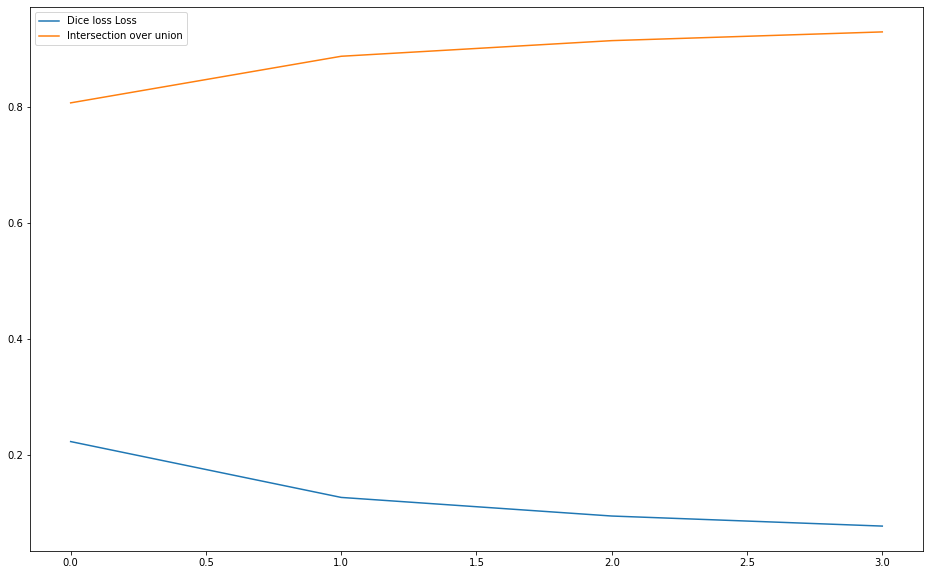

In [12]:
 import matplotlib.pyplot as plt 
f = plt.figure(figsize=(16, 10))
plt.plot(train_loss, label='Dice loss Loss')
plt.plot(train_iou, label='Intersection over union')
plt.legend()
plt.show()